# A Python Analysis of Stock Returns and Volatility: Comparing Apple, Microsoft, and Tesla

## Problem Definition
This project aims to analyse and compare the stock performance of Apple (AAPL), Microsoft (MSFT), and Tesla (TSLA) compared to SPY in 2023 using historical data from WRDS.

The target users include beginner investors who want to understand stock price trends, return behaviour, risk and volatility.

In [1]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
## Connecting to WRDS
db = wrds.Connection()

Enter your WRDS username [chang]: changzei
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  n


You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [16]:
db.list_libraries()

['aha_sample',
 'ahasamp',
 'auditsmp',
 'auditsmp_all',
 'bank',
 'bank_all',
 'bank_premium_samp',
 'banksamp',
 'block',
 'block_all',
 'boardex_trial',
 'boardsmp',
 'bvd',
 'bvd_amadeus_trial',
 'bvd_bvdbankf',
 'bvd_bvdbankf_trial',
 'bvd_orbis_trial',
 'bvdsamp',
 'calcbench_trial',
 'calcbnch',
 'candid_samp',
 'cboe',
 'cboe_all',
 'cboe_sample',
 'cboesamp',
 'cddsamp',
 'ciq',
 'ciq_capstrct',
 'ciq_common',
 'ciqsamp',
 'ciqsamp_capstrct',
 'ciqsamp_common',
 'ciqsamp_keydev',
 'ciqsamp_pplintel',
 'ciqsamp_ratings',
 'ciqsamp_transactions',
 'ciqsamp_transcripts',
 'cisdmsmp',
 'columnar',
 'comp',
 'comp_execucomp',
 'comp_global_daily',
 'comp_na_daily_all',
 'comp_urq',
 'comph',
 'compsamp',
 'compsamp_all',
 'compsamp_computext',
 'compsamp_snapshot',
 'contrib',
 'contrib_as_filed_financials',
 'contrib_bond_firm_link',
 'contrib_ceo_turnover',
 'contrib_char_returns',
 'contrib_corporate_culture',
 'contrib_general',
 'contrib_global_factor',
 'contrib_intangible_va

## Data Extraction

In [17]:
query = """
SELECT a.date, a.permno, b.ticker, b.comnam, a.prc, a.ret, a.vol
FROM crsp.dsf AS a
JOIN crsp.stocknames AS b
ON a.permno = b.permno
AND a.date >= b.namedt
AND a.date <= b.nameenddt
WHERE b.ticker IN ('AAPL', 'MSFT', 'TSLA','SPY')
AND a.date BETWEEN '2023-01-01' AND '2023-12-31'
LIMIT 70000
"""

stock_df = db.raw_sql(query)
stock_df.head()

,date,permno,ticker,comnam,prc,ret,vol
0,2023-01-03,10107,MSFT,MICROSOFT CORP,239.58,-0.001001,25723760.0
1,2023-01-04,10107,MSFT,MICROSOFT CORP,229.10001,-0.043743,50564994.0
2,2023-01-05,10107,MSFT,MICROSOFT CORP,222.31,-0.029638,39541865.0
3,2023-01-06,10107,MSFT,MICROSOFT CORP,224.92999,0.011785,43569634.0
4,2023-01-09,10107,MSFT,MICROSOFT CORP,227.12,0.009736,27334038.0


In [18]:
## Confirm the ticker
stock_df['ticker'].unique()

<StringArray>
['MSFT', 'AAPL', 'SPY', 'TSLA']
Length: 4, dtype: string

Data Source: The dataset was obtained from WRDS, using the CRSP daily stock file (crsp.dsf) and company name table (crsp.stocknames).

Access Date: Data accessed on 11 April 2026.
The sample includes daily observations for AAPL, MSFT, TSLA and SPY from 1 January 2023 to 31 December 2023.

## Data Cleaning and Preparation

Before conducting the analysis, the dataset is cleaned and prepared to ensure accuracy and consistency.

The following steps are performed:

1. Convert the date column into datetime format for proper time-series analysis  
2. Sort the dataset by ticker and date to maintain chronological order  
3. Check for missing values and ensure data completeness  
4. Ensure numerical columns (price and return) are correctly formatted  
5. Prepare the dataset for rolling volatility calculation  

These steps are essential to avoid errors in later analysis, especially for time-series calculations such as returns and volatility.

In [19]:
## Data Cleaning

# 1. Convert date to datetime format
stock_df['date'] = pd.to_datetime(stock_df['date'])

# 2. Sort values for time-series analysis
stock_df = stock_df.sort_values(by=['ticker', 'date'])

# 3. Check missing values
missing_values = stock_df.isnull().sum()
print("Missing values in each column:\n", missing_values)

# 4. Ensure numeric data types
stock_df['prc'] = pd.to_numeric(stock_df['prc'], errors='coerce')
stock_df['prc'] = stock_df['prc'].abs()
stock_df['ret'] = pd.to_numeric(stock_df['ret'], errors='coerce')

# 5. Drop rows with missing returns (if necessary for analysis)
stock_df = stock_df.dropna(subset=['ret'])

# Preview cleaned data
stock_df.head()

Missing values in each column:
 date      0
permno    0
ticker    0
comnam    0
prc       0
ret       0
vol       0
dtype: int64


,date,permno,ticker,comnam,prc,ret,vol
250,2023-01-03,14593,AAPL,APPLE INC,125.07,-0.037405,111953221.0
251,2023-01-04,14593,AAPL,APPLE INC,126.36,0.010314,89022192.0
252,2023-01-05,14593,AAPL,APPLE INC,125.02,-0.010605,81128113.0
253,2023-01-06,14593,AAPL,APPLE INC,129.62,0.036794,87654520.0
254,2023-01-09,14593,AAPL,APPLE INC,130.14999,0.004089,70700396.0


### Data Cleaning Notes

- Sorting by ticker and date ensures that calculations such as returns and rolling volatility are performed in the correct chronological order.  
- Missing values in return (`ret`) may occur due to non-trading days or data gaps and are removed to avoid distortion in analysis.  
- Converting columns to numeric format ensures that mathematical operations can be performed correctly.  

For rolling volatility (30-day standard deviation), the first 29 observations for each stock will naturally result in missing values, as at least 30 data points are required to compute the statistic. This is expected and does not indicate an error in the dataset.

## Code Optimization: Function for Plotting

To improve code readability and avoid repetition, a function is defined to handle time series plotting for different variables such as price and volatility.

In [20]:
def plot_time_series(data, value_col, title, y_label):
    plt.figure(figsize=(12,6))
    
    for ticker in data['ticker'].unique():
        subset = data[data['ticker'] == ticker]
        plt.plot(subset['date'], subset[value_col], label=ticker)
    
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel(y_label)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Price Visualization
We plotted the stock prices of AAPL, MSFT, TSLA and SPY over the year 2023 to compare their performance.
SPY is used as a proxy for the S&P 500 benchmark.

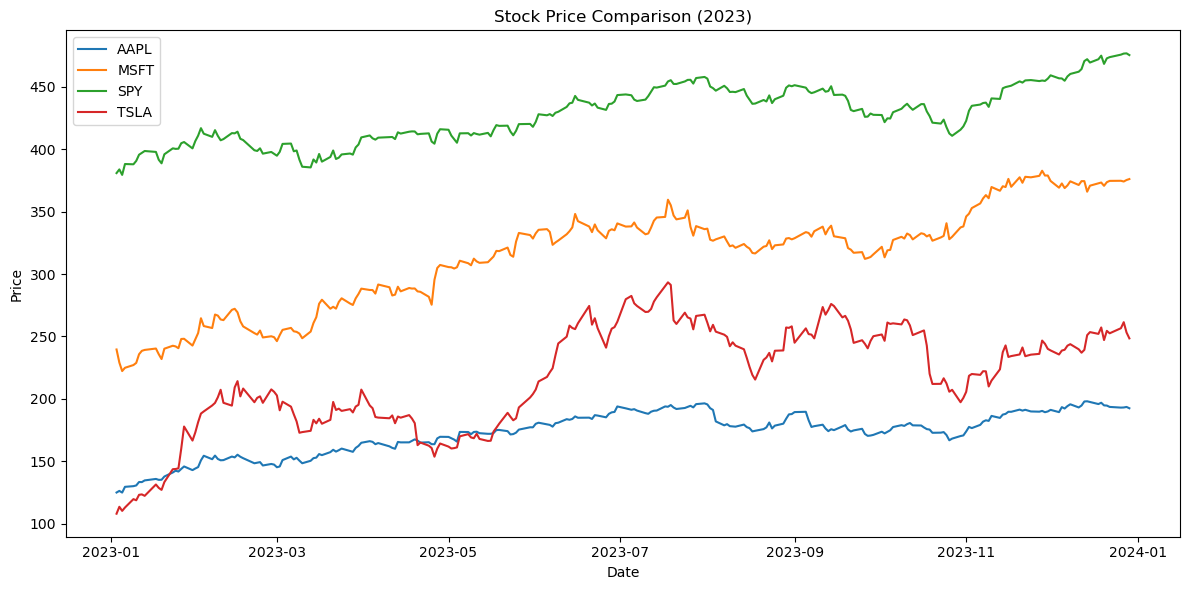

In [21]:
plot_time_series(
    stock_df,
    'prc',
    'Stock Price Comparison (2023)',
    'Price'
)

The line chart illustrates the daily stock prices of AAPL, MSFT, TSLA, and the S&P 500 in 2023.

From the graph, we can observe clear differences in performance and volatility among the three companies compared to the overall market:

MSFT shows a strong and consistent upward trend throughout the year, outperforming the S&P 500 and indicating stable growth and strong market performance.  
AAPL demonstrates moderate growth with relatively small fluctuations, moving more closely with the S&P 500, suggesting stable but less aggressive performance.  
TSLA exhibits significant volatility, with large price swings over time, fluctuating much more than the S&P 500, which indicates higher risk and uncertainty.

Overall, MSFT appears to have the best performance in terms of growth, while TSLA carries the highest risk due to its high volatility. Compared with the benchmark, AAPL and MSFT are relatively more stable, whereas TSLA is more volatile than the overall market.

### Return Analysis
We calculated the average daily return for each stock to compare their profitability.

In [44]:
### Function for Return and Risk Calculation

def calculate_metrics(df):
    mean_ret = df.groupby('ticker')['ret'].mean()
    risk = df.groupby('ticker')['ret'].std()
    return mean_ret, risk

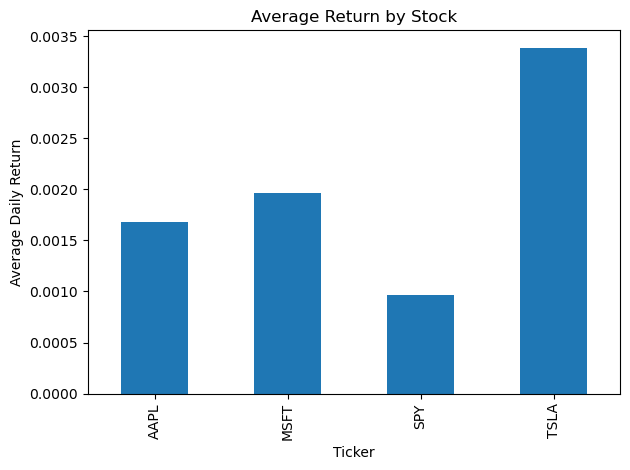

In [45]:
mean_ret, risk = calculate_metrics(stock_df)

mean_ret.plot(kind='bar')
plt.title('Average Return by Stock')
plt.xlabel('Ticker')
plt.ylabel('Average Daily Return')
plt.tight_layout()
plt.show()

The chart shows that TSLA has the highest average return, followed by MSFT and AAPL.

### Risk Analysis
We measure risk using the standard deviation of daily returns. A higher value indicates greater volatility and higher risk.

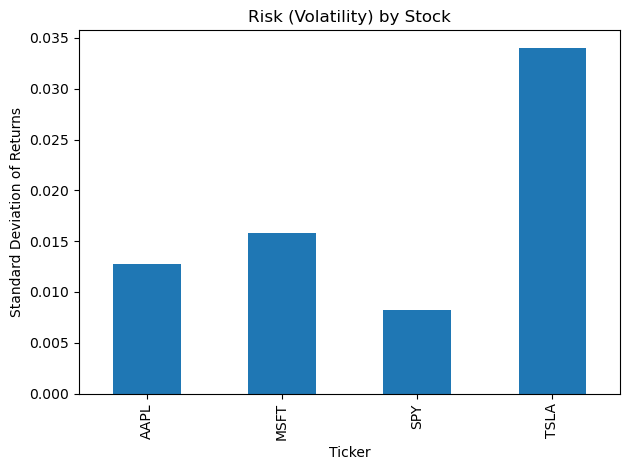

In [39]:
risk.plot(kind='bar')
plt.title('Risk (Volatility) by Stock')
plt.xlabel('Ticker')
plt.ylabel('Standard Deviation of Returns')
plt.tight_layout()
plt.show()

The chart shows differences in risk among the three companies and the market benchmark. TSLA has the highest standard deviation, indicating greater fluctuations in returns and higher risk, while AAPL and MSFT are relatively more stable.

Compared with SPY, used as a proxy for the S&P 500, AAPL and MSFT have risk levels closer to the overall market, whereas TSLA remains significantly more volatile. The similar ranking between return and risk suggests a typical risk–return trade-off, where higher potential returns are associated with higher volatility.

## Volatility Analysis

This section analyses and compares the volatility of Apple (AAPL), Microsoft (MSFT), Tesla (TSLA), and the market benchmark SPY.

Volatility measures how much stock returns fluctuate over time. In this analysis, 30-day rolling volatility is used to show changes in risk over the year.

The first 29 observations for each stock are missing because 30 days of return data are required to calculate rolling volatility. This is normal and does not indicate an error.

In [40]:
# Calculate 30-day rolling volatility
stock_df['volatility'] = stock_df.groupby('ticker')['ret'].rolling(30).std().reset_index(level=0, drop=True)

# Remove missing values for plotting and summary
volatility_df = stock_df.dropna(subset=['volatility'])

volatility_df.head()

,date,permno,ticker,comnam,prc,ret,vol,volatility
279,2023-02-14,14593,AAPL,APPLE INC,153.2,-0.004225,61665183.0,0.016699
280,2023-02-15,14593,AAPL,APPLE INC,155.33,0.013903,65611726.0,0.014632
281,2023-02-16,14593,AAPL,APPLE INC,153.71001,-0.010429,68101396.0,0.014976
282,2023-02-17,14593,AAPL,APPLE INC,152.55,-0.007547,59122868.0,0.014864
283,2023-02-21,14593,AAPL,APPLE INC,148.48,-0.02668,64658637.0,0.014966


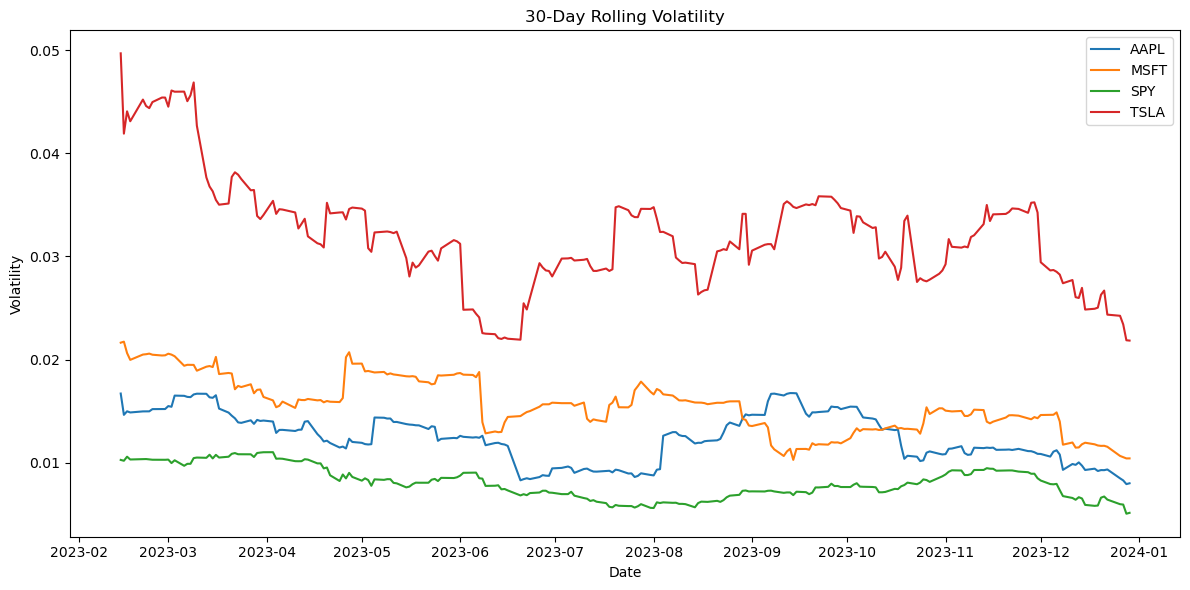

In [41]:
plot_time_series(
    volatility_df,
    'volatility',
    '30-Day Rolling Volatility',
    'Volatility'
)

The chart shows clear differences in volatility among the three companies and the market benchmark. Tesla (TSLA) exhibits the highest volatility, indicating greater fluctuations in returns and higher short-term risk. In contrast, Apple (AAPL) and Microsoft (MSFT) show more stable volatility levels.

Compared with SPY, used as a proxy for the S&P 500, AAPL and MSFT have volatility closer to the overall market, while TSLA remains significantly more volatile. Overall, volatility changes over time with market conditions, highlighting the importance of considering both risk and return when evaluating stock performance.

In [42]:
avg_volatility = volatility_df.groupby('ticker')['volatility'].mean().reset_index()
avg_volatility.columns = ['Ticker', 'Average_30Day_Volatility']
avg_volatility

,Ticker,Average_30Day_Volatility
0,AAPL,0.012414
1,MSFT,0.015568
2,SPY,0.008056
3,TSLA,0.032133


### Average Volatility Interpretation

The table shows that TSLA has the highest average volatility, indicating the greatest level of risk among the three stocks. MSFT has the lowest average volatility, suggesting more stable performance, while AAPL falls in between.

This reinforces the earlier observation from the volatility chart that higher potential returns are often associated with higher risk. Therefore, investors should consider their risk tolerance when choosing between these stocks.

## Conclusion
In this analysis, we examined the stock performance of AAPL, MSFT, and TSLA in 2023, focusing on price trends, return behaviour, and volatility, with the S&P 500 (SPY) used as a market benchmark.

MSFT shows relatively stable growth, making it a reliable investment option. AAPL demonstrates steady performance with lower risk, while TSLA provides the highest returns but also carries the highest risk due to its greater volatility.

For beginner investors, more stable stocks such as MSFT and AAPL may be more suitable, while TSLA may be appropriate for those willing to accept higher risk for potentially higher returns.

Overall, this analysis highlights the importance of considering both return, risk and volatility when making investment decisions, especially when compared with the overall market benchmark.